# 🏭 RL Scheduling - Generalized Training

Randomizes **everything** each episode: products, work centers, operations, routing, POs, qty.
Model learns general scheduling strategies, not factory-specific patterns.

In [ ]:
%pip install gymnasium stable-baselines3 numpy matplotlib torch --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 18.2 MB/s eta 0:00:00


In [ ]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [ ]:
@dataclass
class ShiftWindow:
    start_min: int
    end_min: int

@dataclass
class WorkCenterConfig:
    id: int
    name: str
    operation_id: int
    capacity_per_hour: float
    workers_required: int = 1
    cost_per_hour: float = 0.0
    shifts: Dict[int, List[ShiftWindow]] = field(default_factory=dict)

@dataclass
class JobTask:
    job_id: int
    task_idx: int
    operation_id: int
    setup_time: int
    quantity: int
    predecessors: List[int] = field(default_factory=list)

@dataclass
class ScheduledTask:
    job_id: int
    task_idx: int
    machine_id: int
    start: int
    end: int

## Generalized Problem Generator

In [ ]:
class GeneralizedGenerator:
    """
    Randomizes: WC count/capacity/shifts, products, routing DAGs, POs, qty.
    Creates realistic manufacturing patterns with parallel sub-assemblies.
    """
    CAPS = [3, 4, 6, 8, 10, 12, 15, 20, 30, 60, 90, 120]

    def __init__(self, seed=None):
        self.rng = np.random.RandomState(seed)

    def _random_shifts(self):
        p = self.rng.randint(0, 4)
        shifts = {}
        days = range(1, 7) if p >= 2 else range(1, 6)
        windows = [ShiftWindow(480, 960)]
        if p % 2 == 0:
            windows.append(ShiftWindow(960, 1440))
        for d in days:
            shifts[d] = list(windows)
        return shifts

    def _make_routing(self, op_pool):
        """Create a DAG: 2-4 parallel sub-assembly chains → final merge chain."""
        n_branches = self.rng.randint(2, 5)
        branch_len = [int(self.rng.randint(2, 6)) for _ in range(n_branches)]
        final_len = int(self.rng.randint(3, 9))
        total = sum(branch_len) + final_len
        if total > len(op_pool):
            total = len(op_pool)
            final_len = max(2, total - sum(branch_len))
            while sum(branch_len) + final_len > total:
                idx = self.rng.randint(0, len(branch_len))
                if branch_len[idx] > 2: branch_len[idx] -= 1

        ops = self.rng.choice(op_pool, size=min(total, len(op_pool)), replace=False).tolist()
        routing = []
        idx = 0
        branch_ends = []
        for b in range(n_branches):
            for s in range(branch_len[b]):
                if idx >= len(ops): break
                setup = int(self.rng.randint(5, 50))
                preds = [idx - 1] if s > 0 else []
                routing.append((ops[idx], setup, preds))
                idx += 1
            if idx > 0: branch_ends.append(idx - 1)

        for s in range(final_len):
            if idx >= len(ops): break
            setup = int(self.rng.randint(5, 50))
            if s == 0:
                preds = [e for e in branch_ends if e < idx]
            else:
                preds = [idx - 1]
            routing.append((ops[idx], setup, preds))
            idx += 1
        return routing

    def generate(self):
        n_wc = int(self.rng.randint(30, 61))
        work_centers = {}
        for i in range(n_wc):
            cap = float(self.rng.choice(self.CAPS))
            work_centers[i] = WorkCenterConfig(
                id=i, name=f'WC-{i:03d}', operation_id=0,
                capacity_per_hour=cap, workers_required=int(self.rng.randint(5, 12)),
                shifts=self._random_shifts()
            )

        n_ops = int(self.rng.randint(40, 100))
        op_ids = list(range(100, 100 + n_ops))
        op_to_wc = {}
        for op_id in op_ids:
            n = min(int(self.rng.randint(5, 12)), n_wc)
            op_to_wc[op_id] = self.rng.choice(n_wc, size=n, replace=False).tolist()

        n_products = int(self.rng.randint(5, 12))
        product_routings = [self._make_routing(op_ids) for _ in range(n_products)]

        n_orders = int(self.rng.randint(10, 30))
        jobs = []
        for i in range(n_orders):
            qty = int(self.rng.randint(20, 100))
            routing = product_routings[self.rng.randint(0, n_products)]
            job_tasks = []
            for t_idx, (op_id, setup, preds) in enumerate(routing):
                job_tasks.append(JobTask(
                    job_id=i, task_idx=t_idx, operation_id=op_id,
                    setup_time=setup, quantity=qty, predecessors=list(preds)
                ))
            jobs.append(job_tasks)

        return {
            'jobs': jobs, 'work_centers': work_centers, 'op_to_wc': op_to_wc,
            'holidays': set(), 'max_workers': 600, 'horizon_days': 120,
        }

## Environment (Task-Only Action + Auto Fastest Machine)

In [ ]:
class JSSPEnv(gym.Env):
    metadata = {"render_modes": ["human"]}

    def __init__(self, instance=None, generator_seed=None):
        super().__init__()
        self.generator = GeneralizedGenerator(seed=generator_seed)
        self.instance = instance
        self._setup_from_instance(instance or self.generator.generate())
        self.MAX_TASKS = 1000
        self.MAX_MACHINES = 100
        self.action_space = spaces.Discrete(self.MAX_TASKS)
        task_feat = 7; machine_feat = 4; global_feat = 3
        obs_size = self.MAX_TASKS * task_feat + self.MAX_MACHINES * machine_feat + global_feat
        self.obs_size = obs_size
        self.task_feat = task_feat
        self.machine_feat = machine_feat
        self.observation_space = spaces.Box(low=-1.0, high=1.0, shape=(obs_size,), dtype=np.float32)

    def _setup_from_instance(self, instance):
        self.jobs = instance['jobs']
        self.work_centers = instance['work_centers']
        self.op_to_wc = instance['op_to_wc']
        self.holidays = instance['holidays']
        self.horizon_days = instance['horizon_days']
        self.horizon_minutes = self.horizon_days * 1440
        self.all_tasks = []
        self.task_global_idx = {}
        for job in self.jobs:
            for task in job:
                g = len(self.all_tasks)
                self.task_global_idx[(task.job_id, task.task_idx)] = g
                self.all_tasks.append(task)
        self.n_tasks = len(self.all_tasks)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if options and options.get('new_instance', False):
            self._setup_from_instance(self.generator.generate())
        elif self.instance is None:
            self._setup_from_instance(self.generator.generate())
        self.scheduled = [None] * self.n_tasks
        self.machine_timeline = {m: [] for m in self.work_centers}
        self.machine_available_time = {m: 0 for m in self.work_centers}
        self.n_scheduled = 0
        self.current_makespan = 0
        self.proc_times = {}
        for g_idx, task in enumerate(self.all_tasks):
            for wc_id in self.op_to_wc.get(task.operation_id, []):
                wc = self.work_centers.get(wc_id)
                if wc and wc.capacity_per_hour > 0:
                    pt = int(task.quantity * (60 / wc.capacity_per_hour))
                    self.proc_times[(g_idx, wc_id)] = task.setup_time + pt
        return self._get_obs(), {}

    def _is_holiday(self, m): return (m // 1440) in self.holidays
    def _is_in_shift(self, mid, m):
        wc = self.work_centers.get(mid)
        if not wc: return False
        for sw in wc.shifts.get(((m//1440)%7)+1, []):
            if sw.start_min <= m%1440 < sw.end_min: return True
        return False
    def _shift_end_at(self, mid, m):
        wc = self.work_centers.get(mid)
        if not wc: return -1
        d = m // 1440
        for sw in wc.shifts.get((d%7)+1, []):
            if sw.start_min <= m%1440 < sw.end_min: return d*1440+sw.end_min
        return -1
    def _next_shift_start(self, mid, m):
        wc = self.work_centers.get(mid)
        if not wc: return self.horizon_minutes
        t = m
        for _ in range(self.horizon_days*2):
            d = t // 1440
            if d*1440 >= self.horizon_minutes: return self.horizon_minutes
            for sw in sorted(wc.shifts.get((d%7)+1,[]), key=lambda s:s.start_min):
                if sw.start_min >= t%1440:
                    c = d*1440+sw.start_min
                    if not self._is_holiday(c): return c
            t = (d+1)*1440
        return self.horizon_minutes
    def _continuous_work_end(self, mid, start):
        cur = start
        for _ in range(20):
            se = self._shift_end_at(mid, cur)
            if se == -1: break
            if not self._is_holiday(se) and self._is_in_shift(mid, se): cur = se
            else: return se
        return cur

    def _get_valid_tasks(self):
        valid = {}
        for g, task in enumerate(self.all_tasks):
            if self.scheduled[g] is not None: continue
            ok = all(self.scheduled[self.task_global_idx.get((task.job_id,p),-1)] is not None
                     for p in task.predecessors if self.task_global_idx.get((task.job_id,p)) is not None)
            if not ok: continue
            ms = self.op_to_wc.get(task.operation_id, [])
            if ms: valid[g] = ms
        return valid

    def _get_earliest_start(self, gi, mid):
        task = self.all_tasks[gi]
        dur = self.proc_times.get((gi, mid), 60)
        e = 0
        for p in task.predecessors:
            pg = self.task_global_idx.get((task.job_id, p))
            if pg is not None and self.scheduled[pg]: e = max(e, self.scheduled[pg].end)
        e = max(e, self.machine_available_time.get(mid, 0))
        return self._find_slot(mid, e, dur)

    def _find_slot(self, mid, earliest, dur):
        t = earliest
        for _ in range(100000):
            if t >= self.horizon_minutes: return self.horizon_minutes
            if self._is_holiday(t): t=((t//1440)+1)*1440; continue
            if not self._is_in_shift(mid, t): t=self._next_shift_start(mid, t); continue
            if t+dur > self._continuous_work_end(mid, t):
                t = self._next_shift_start(mid, self._continuous_work_end(mid, t)); continue
            overlap = False
            for (s,e) in self.machine_timeline[mid]:
                if t < e and t+dur > s: overlap=True; t=e; break
            if not overlap: return t
        return self.horizon_minutes

    def _select_best_machine(self, gi, mids):
        best_m, best_end = None, float('inf')
        for mid in mids:
            dur = self.proc_times.get((gi, mid), 60)
            end = self._get_earliest_start(gi, mid) + dur
            if end < best_end: best_end = end; best_m = mid
        return best_m

    def _get_obs(self):
        obs = np.zeros(self.obs_size, dtype=np.float32)
        norm = max(self.horizon_minutes, 1)
        for i in range(min(self.n_tasks, self.MAX_TASKS)):
            t = self.all_tasks[i]; b = i * self.task_feat
            obs[b] = 1.0
            if self.scheduled[i]: obs[b+1] = 1.0
            n_alt = len(self.op_to_wc.get(t.operation_id, []))
            obs[b+2] = min(n_alt / 10.0, 1.0)  # flexibility
            pts = [self.proc_times.get((i,m),0) for m in self.op_to_wc.get(t.operation_id,[])]
            obs[b+3] = min((np.mean(pts) if pts else 0) / norm, 1.0)
            obs[b+4] = t.setup_time / max(norm, 1)
            obs[b+5] = min(t.quantity / 50.0, 1.0)
            np_ = len(t.predecessors)
            if np_ > 0:
                done = sum(1 for p in t.predecessors
                          if self.task_global_idx.get((t.job_id,p)) is not None
                          and self.scheduled[self.task_global_idx[(t.job_id,p)]] is not None)
                obs[b+6] = done / np_
            else: obs[b+6] = 1.0
        mb = self.MAX_TASKS * self.task_feat
        for i, mid in enumerate(sorted(self.work_centers.keys())):
            if i >= self.MAX_MACHINES: break
            b = mb + i * self.machine_feat
            obs[b] = 1.0
            obs[b+1] = min(self.machine_available_time.get(mid,0)/norm, 1.0)
            obs[b+2] = min(sum(e-s for s,e in self.machine_timeline[mid])/norm, 1.0)
            nq = sum(1 for g,tk in enumerate(self.all_tasks)
                    if not self.scheduled[g] and mid in self.op_to_wc.get(tk.operation_id,[]))
            obs[b+3] = min(nq / max(self.n_tasks,1), 1.0)
        gb = mb + self.MAX_MACHINES * self.machine_feat
        obs[gb] = self.n_scheduled / max(self.n_tasks, 1)
        obs[gb+1] = min(self.current_makespan / norm, 1.0)
        vt = self._get_valid_tasks()
        obs[gb+2] = len(vt) / max(self.n_tasks, 1)
        return obs

    def step(self, action):
        vt = self._get_valid_tasks()
        if not vt:
            return self._get_obs(), -self.current_makespan/self.horizon_minutes, True, False, {'makespan': self.current_makespan}
        task_a = action % self.MAX_TASKS
        best_task = min(vt.keys(), key=lambda t: abs(t - task_a))
        mid = self._select_best_machine(best_task, vt[best_task])
        if mid is None: return self._get_obs(), -1.0, True, False, {}
        task = self.all_tasks[best_task]
        dur = self.proc_times.get((best_task, mid), 60)
        start = self._get_earliest_start(best_task, mid)
        end = start + dur
        self.scheduled[best_task] = ScheduledTask(task.job_id, task.task_idx, mid, start, end)
        self.machine_timeline[mid].append((start, end))
        self.machine_timeline[mid].sort()
        self.machine_available_time[mid] = end
        self.n_scheduled += 1
        self.current_makespan = max(self.current_makespan, end)
        done = self.n_scheduled >= self.n_tasks
        reward = -self.current_makespan/self.horizon_minutes if done else -0.01*(end/self.horizon_minutes)
        return self._get_obs(), reward, done, False, {'makespan': self.current_makespan}

    def render(self):
        fig, ax = plt.subplots(figsize=(20, 10))
        colors = plt.cm.tab20(np.linspace(0, 1, max(len(self.jobs), 1)))
        active = sorted([m for m in self.work_centers if self.machine_timeline[m]])
        if not active: active = sorted(self.work_centers.keys())[:10]
        for y, mid in enumerate(active):
            wc = self.work_centers[mid]
            for day in range((self.current_makespan+480)//1440+1):
                for sw in wc.shifts.get((day%7)+1, []):
                    s,e = day*1440+sw.start_min, day*1440+sw.end_min
                    c = '#e8f5e9' if sw.start_min < 960 else '#fff3e0'
                    ax.barh(y, e-s, left=s, height=0.9, color=c, alpha=0.3)
        for gi, st in enumerate(self.scheduled):
            if st is None or st.machine_id not in active: continue
            y = active.index(st.machine_id)
            ax.barh(y, st.end-st.start, left=st.start, height=0.6,
                    color=colors[st.job_id%len(colors)], edgecolor='black', linewidth=0.3)
        ax.set_yticks(range(len(active)))
        ax.set_yticklabels([self.work_centers[m].name for m in active], fontsize=6)
        ax.set_title(f'Makespan: {self.current_makespan} min ({self.current_makespan/1440:.1f} days)')
        plt.tight_layout(); plt.show()

## Verification

In [ ]:
for trial in range(3):
    gen = GeneralizedGenerator(seed=trial)
    inst = gen.generate()
    n_tasks = sum(len(j) for j in inst['jobs'])
    qtys = [j[0].quantity for j in inst['jobs']]
    print(f'Trial {trial}: WCs={len(inst["work_centers"])}, Ops={len(inst["op_to_wc"])}, '
          f'POs={len(inst["jobs"])}, Tasks={n_tasks}, Qty={qtys}')

# Quick test
env = JSSPEnv(generator_seed=42)
obs, _ = env.reset()
done, steps = False, 0
while not done and steps < 500:
    obs, _, done, _, info = env.step(env.action_space.sample()); steps += 1
print(f'\nRandom: {env.n_scheduled}/{env.n_tasks} tasks, '
      f'makespan={env.current_makespan/1440:.1f} days')

Trial 0: WCs=42, Ops=53, POs=14, Tasks=232, Qty=[24, 99, 41, 30, 22, 81, 52, 43, 21, 28, 20, 46, 72, 42]
Trial 1: WCs=35, Ops=53, POs=17, Tasks=332, Qty=[72, 41, 99, 87, 92, 96, 78, 78, 83, 57, 43, 20, 42, 79, 22, 23, 34]
Trial 2: WCs=38, Ops=80, POs=19, Tasks=278, Qty=[36, 49, 41, 93, 66, 48, 93, 28, 99, 77, 27, 58, 67, 31, 29, 60, 28, 86, 90]

Random: 276/276 tasks, makespan=7.7 days


## Training

In [ ]:
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import EvalCallback

env = JSSPEnv(generator_seed=42)
eval_env = JSSPEnv(generator_seed=142)

model = PPO(
    "MlpPolicy", env,
    learning_rate=3e-4, n_steps=8192, batch_size=512,
    n_epochs=20, gamma=0.995, verbose=1, seed=42,
    policy_kwargs=dict(net_arch=dict(pi=[512, 512, 256], vf=[512, 512, 256])),
)

eval_cb = EvalCallback(eval_env, best_model_save_path='./best_model/',
                       log_path='./logs/', eval_freq=50000, n_eval_episodes=10)

model.learn(total_timesteps=500_000, callback=eval_cb, progress_bar=True)
model.save('rl_jssp_scheduler')
print('✅ Saved!')

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: 
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects 
to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

Output()

...

-----------------------------------------
| eval/                   |             |
|    mean_ep_length       | 314         |
|    mean_reward          | -0.169      |
| time/                   |             |
|    total_timesteps      | 450000      |
| train/                  |             |
|    approx_kl            | 0.059588887 |
|    clip_fraction        | 0.316       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.23       |
|    explained_variance   | 0.771       |
|    learning_rate        | 0.0003      |
|    loss                 | -0.0295     |
|    n_updates            | 1080        |
|    policy_gradient_loss | -0.016      |
|    value_loss           | 9.24e-05    |
-----------------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 298      |
|    ep_rew_mean     | -0.214   |
| time/              |          |
|    fps             | 94       |
|    iterations      | 55       |
|    t

Eval num_timesteps=500000, episode_reward=-0.25 +/- 0.35

Episode length: 311.00 +/- 86.16

----------------------------------------
| eval/                   |            |
|    mean_ep_length       | 311        |
|    mean_reward          | -0.254     |
| time/                   |            |
|    total_timesteps      | 500000     |
| train/                  |            |
|    approx_kl            | 0.08853029 |
|    clip_fraction        | 0.435      |
|    clip_range           | 0.2        |
|    entropy_loss         | -1.47      |
|    explained_variance   | 0.956      |
|    learning_rate        | 0.0003     |
|    loss                 | -0.0585    |
|    n_updates            | 1220       |
|    policy_gradient_loss | -0.0272    |
|    value_loss           | 1.11e-05   |
----------------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 316      |
|    ep_rew_mean     | -0.217   |
| time/              |          |
|    fps             | 94       |
|    iterations      | 62       |
|    time_elapsed    | 5

✅ Saved!


## Evaluate & Compare

RL vs Random (5 instances):
  #1: RL=8.4d, Rand=7.5d, Imp=-11.7%
  #2: RL=3.4d, Rand=9.9d, Imp=65.8%
  #3: RL=3.7d, Rand=16.4d, Imp=77.7%
  #4: RL=12.4d, Rand=3.4d, Imp=-269.0%
  #5: RL=3.6d, Rand=7.6d, Imp=51.8%
Avg: RL=6.3d, Rand=8.9d, Imp=29.5%


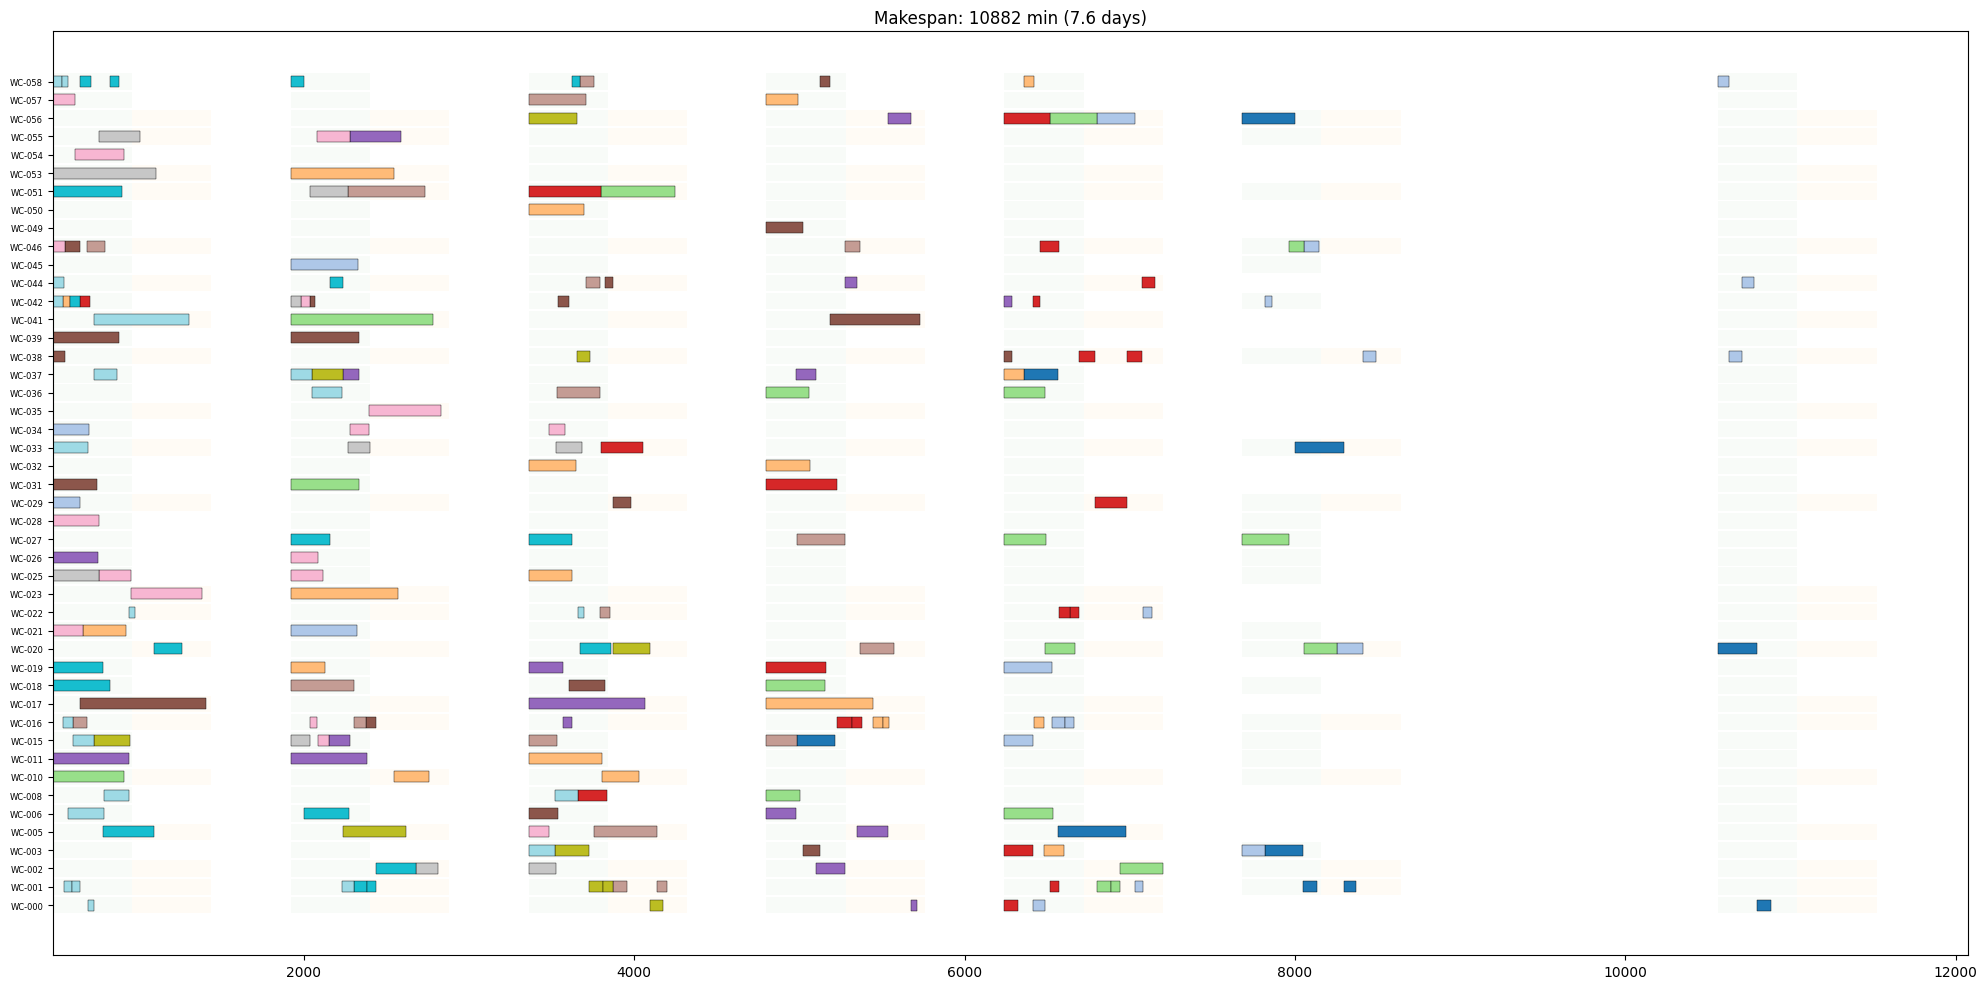

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
n_test = 5
rl_ms, rand_ms = [], []
for i in range(n_test):
    test_env = JSSPEnv(generator_seed=1000+i)
    obs, _ = test_env.reset()
    done = False
    while not done:
        a, _ = model.predict(obs, deterministic=True)
        obs, _, done, _, _ = test_env.step(a)
    rl_ms.append(test_env.current_makespan)

    obs, _ = test_env.reset()
    done = False
    while not done:
        obs, _, done, _, _ = test_env.step(test_env.action_space.sample())
    rand_ms.append(test_env.current_makespan)

print(f'RL vs Random ({n_test} instances):')
for i in range(n_test):
    imp = (rand_ms[i]-rl_ms[i])/rand_ms[i]*100
    print(f'  #{i+1}: RL={rl_ms[i]/1440:.1f}d, Rand={rand_ms[i]/1440:.1f}d, Imp={imp:.1f}%')
print(f'Avg: RL={np.mean(rl_ms)/1440:.1f}d, Rand={np.mean(rand_ms)/1440:.1f}d, '
      f'Imp={(np.mean(rand_ms)-np.mean(rl_ms))/np.mean(rand_ms)*100:.1f}%')

# Show last schedule
test_env.render()